In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

sns.set_style("whitegrid")

BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = BASE_DIR / "data" / "processed"
REPORT_PATH = BASE_DIR / "reports" / "figures"

REPORT_PATH.mkdir(parents=True, exist_ok=True)


In [2]:
fund_master = pd.read_csv(DATA_PATH/"01_fund_master_cleaned.csv")
nav = pd.read_csv(DATA_PATH/"02_nav_history_cleaned.csv")
aum = pd.read_csv(DATA_PATH/"03_aum_by_fund_house_cleaned.csv")
sip = pd.read_csv(DATA_PATH/"04_monthly_sip_inflows_cleaned.csv")
category = pd.read_csv(DATA_PATH/"05_category_inflows_cleaned.csv")
folio = pd.read_csv(DATA_PATH/"06_industry_folio_count_cleaned.csv")
performance = pd.read_csv(DATA_PATH/"07_scheme_performance_cleaned.csv")
investor = pd.read_csv(DATA_PATH/"08_investor_transactions_cleaned.csv")
holding = pd.read_csv(DATA_PATH/"09_portfolio_holdings_cleaned.csv")
benchmark = pd.read_csv(DATA_PATH/"10_benchmark_indices_cleaned.csv")

print("All datasets loaded")

All datasets loaded


In [3]:
nav["date"] = pd.to_datetime(nav["date"])

nav_plot = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [4]:
import plotly.express as px

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022-2026)"
)

In [5]:
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.12,
    annotation_text="Bull Run",
    annotation_position="top left"
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.10,
    annotation_text="Market Correction",
    annotation_position="top right"
)

In [6]:
fig.write_html(REPORT_PATH/"01_nav_trend.html")
print("Chart Saved")

Chart Saved


In [7]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

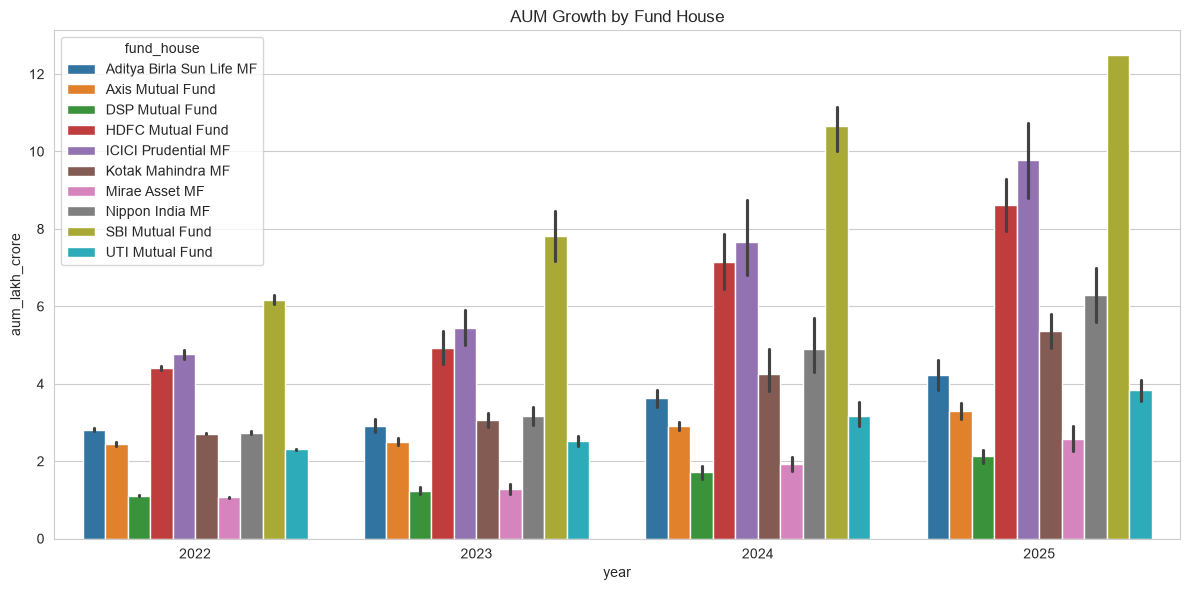

In [8]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.tight_layout()

plt.savefig(REPORT_PATH/"02_aum_growth.png",dpi=300)

plt.show()

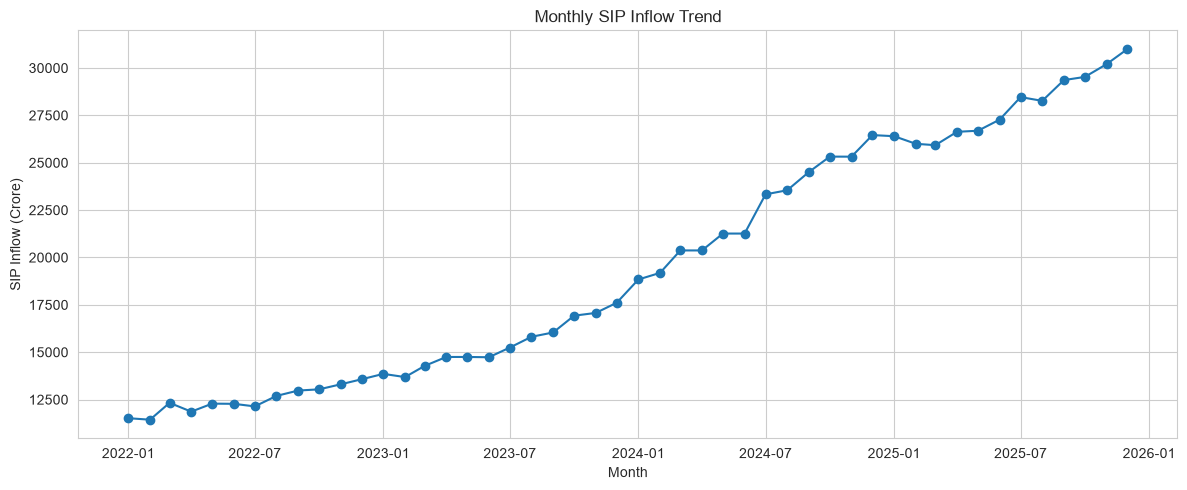

In [9]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,5))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")

plt.tight_layout()

plt.savefig(REPORT_PATH/"03_sip_trend.png",dpi=300)

plt.show()

In [10]:
category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

heatmap_data.head()

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


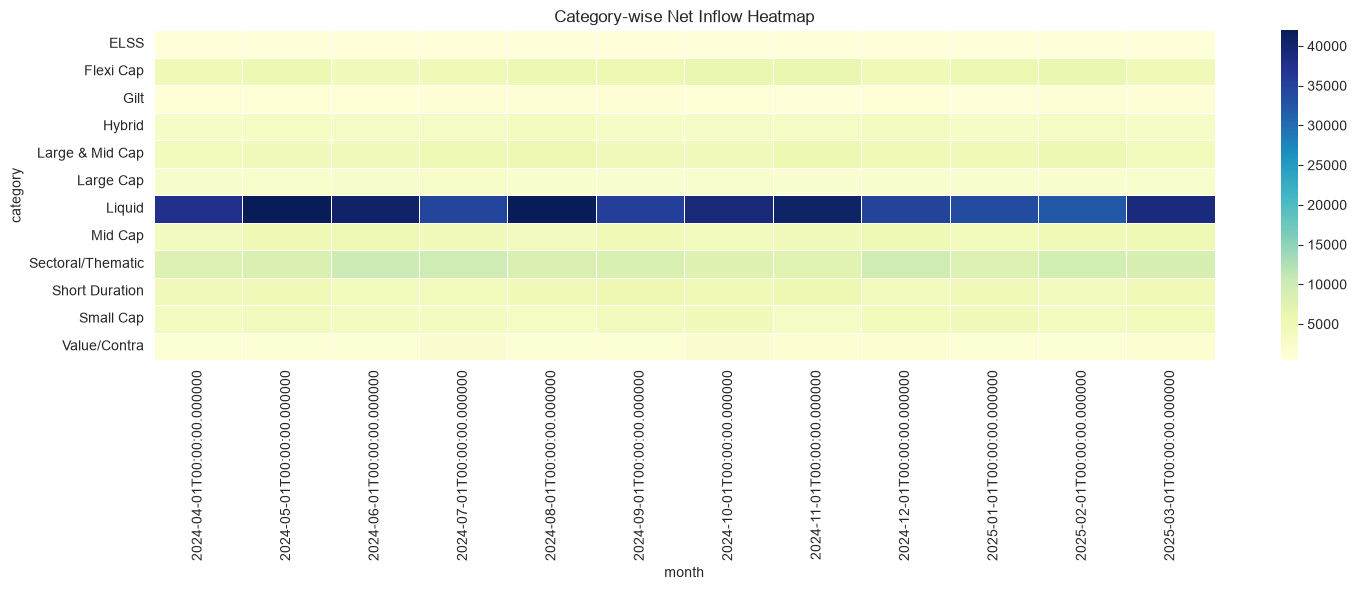

In [11]:
plt.figure(figsize=(15,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap")

plt.tight_layout()

plt.savefig(
    REPORT_PATH/"04_category_heatmap.png",
    dpi=300
)

plt.show()

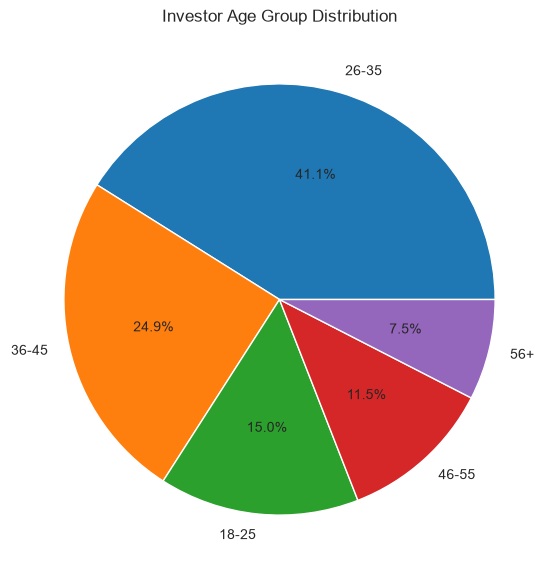

In [12]:
plt.figure(figsize=(7,7))

investor["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Investor Age Group Distribution")

plt.savefig(
    REPORT_PATH/"05_age_group_pie.png",
    dpi=300
)

plt.show()

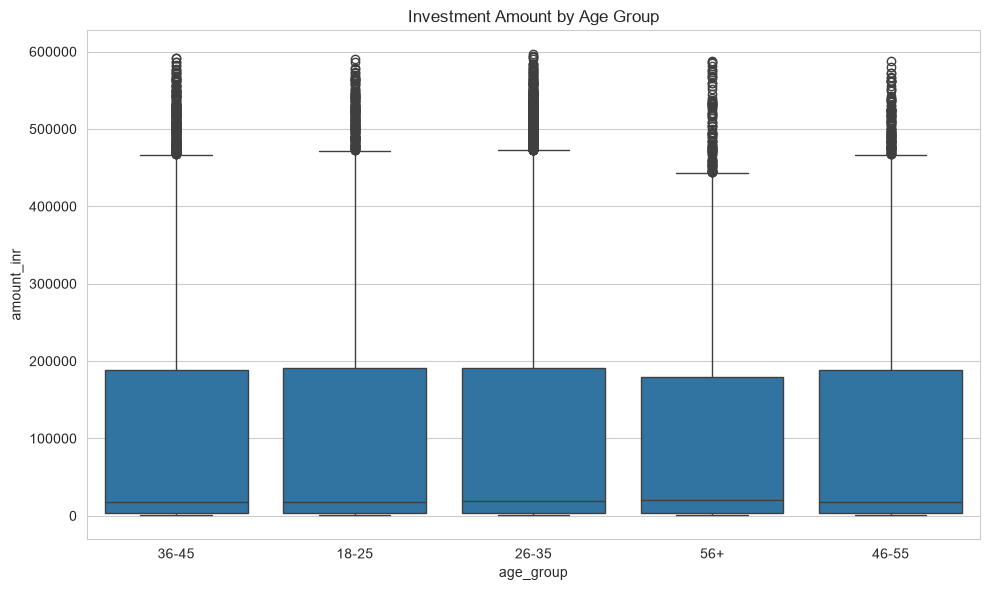

In [13]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.tight_layout()

plt.savefig(
    REPORT_PATH/"06_agegroup_boxplot.png",
    dpi=300
)

plt.show()

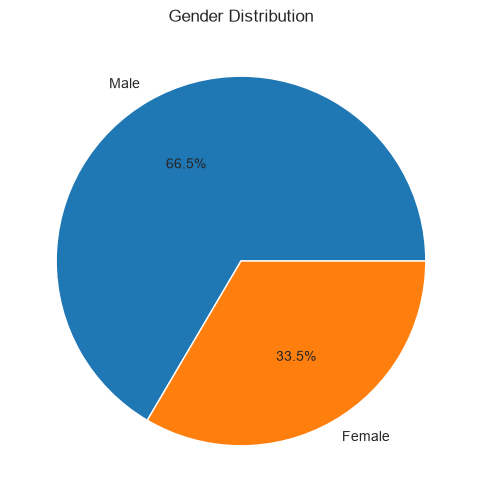

In [14]:
plt.figure(figsize=(6,6))

investor["gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Gender Distribution")

plt.savefig(
    REPORT_PATH/"07_gender_distribution.png",
    dpi=300
)

plt.show()

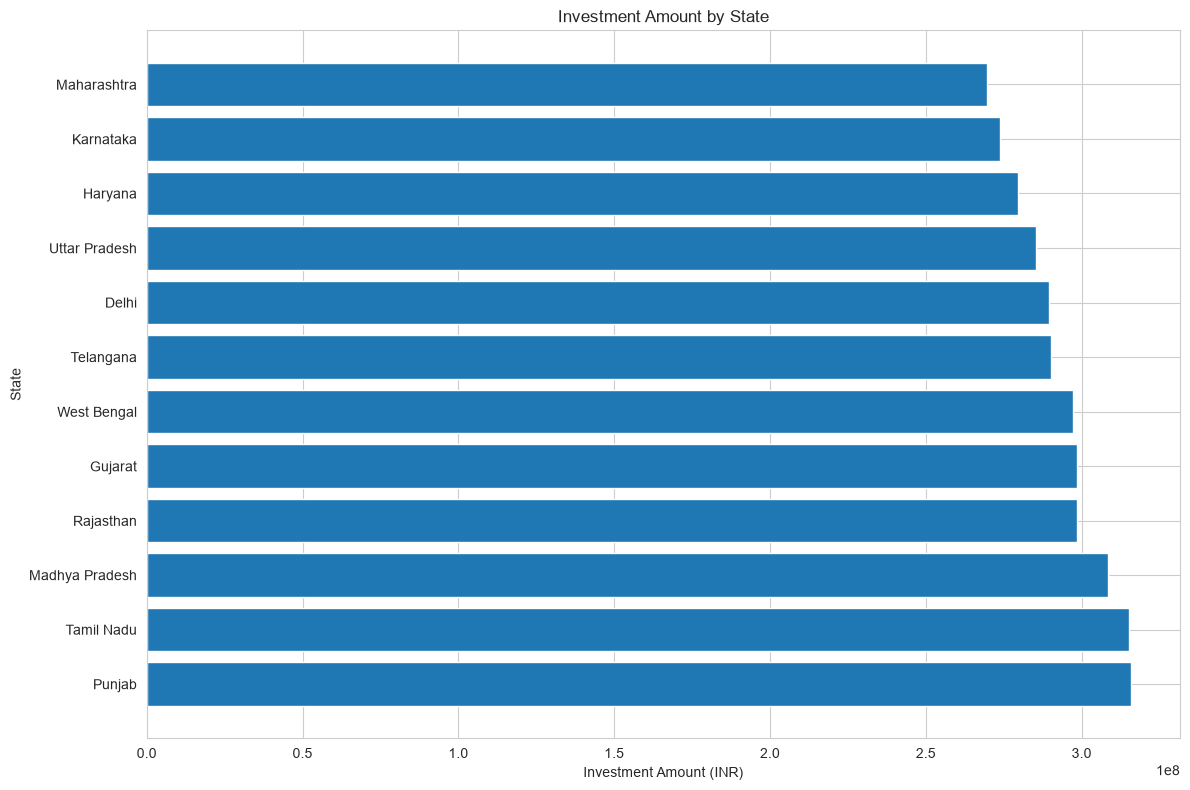

In [15]:
state_data = (
    investor.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

plt.barh(
    state_data.index,
    state_data.values
)

plt.title("Investment Amount by State")
plt.xlabel("Investment Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    REPORT_PATH/"08_state_investment.png",
    dpi=300
)

plt.show()

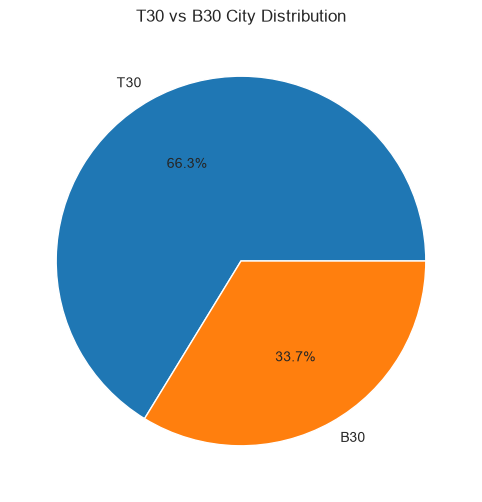

In [16]:
plt.figure(figsize=(6,6))

investor["city_tier"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("T30 vs B30 City Distribution")

plt.savefig(
    REPORT_PATH/"09_city_tier_distribution.png",
    dpi=300
)

plt.show()

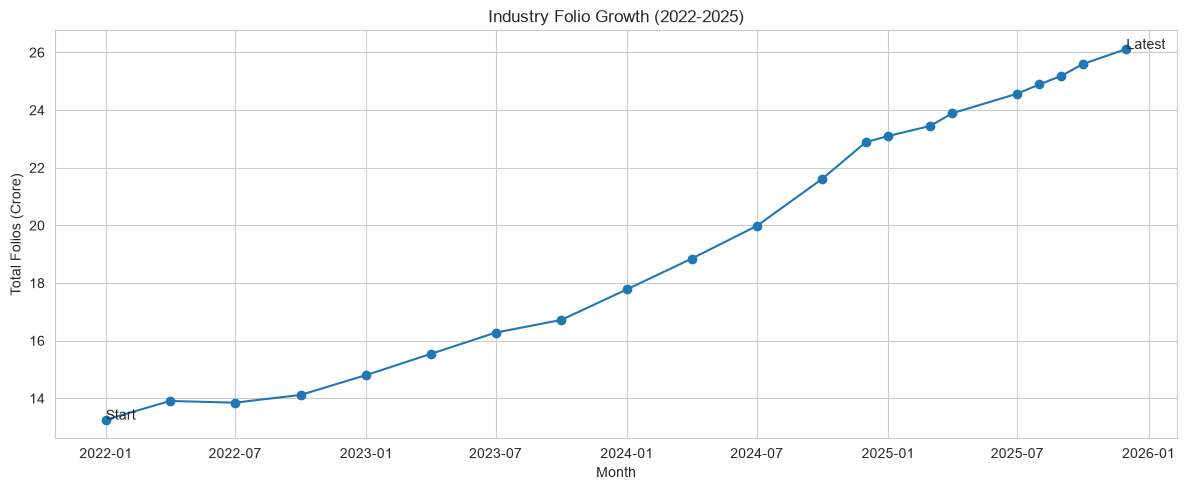

In [17]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,5))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title("Industry Folio Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.annotate(
    "Start",
    (folio.iloc[0]["month"], folio.iloc[0]["total_folios_crore"])
)

plt.annotate(
    "Latest",
    (folio.iloc[-1]["month"], folio.iloc[-1]["total_folios_crore"])
)

plt.tight_layout()

plt.savefig(
    REPORT_PATH/"10_folio_growth.png",
    dpi=300
)

plt.show()

In [18]:
nav["date"] = pd.to_datetime(nav["date"])

pivot_nav = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change()

corr = returns.iloc[:, :10].corr()

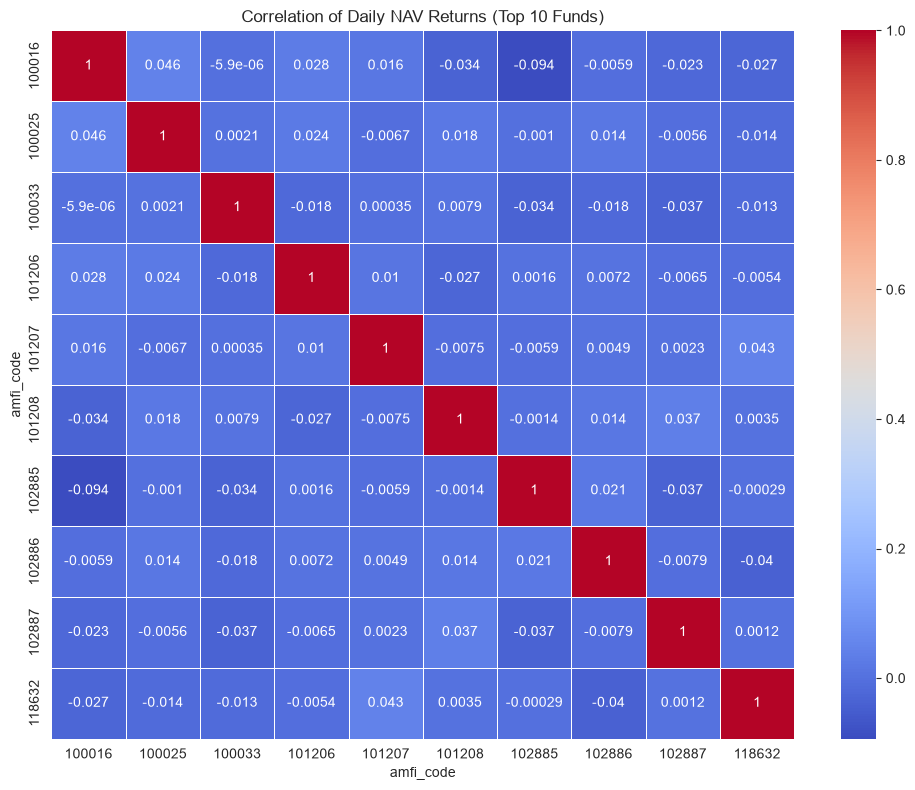

In [19]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation of Daily NAV Returns (Top 10 Funds)")

plt.tight_layout()

plt.savefig(
    REPORT_PATH/"11_nav_correlation.png",
    dpi=300
)

plt.show()

In [20]:
holdings = pd.read_csv(DATA_PATH / "09_portfolio_holdings_cleaned.csv")

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,100016,BAJFINANCE,Bajaj Finance Ltd,NBFC,7.01,214.89,592.41,2025-12-31
1,100016,CIPLA,Cipla Ltd,Pharma,4.92,1325.34,4188.12,2025-12-31
2,100016,DRREDDY,Dr. Reddy's Laboratories,Pharma,9.03,452.67,2212.60,2025-12-31
3,100016,HINDUNILVR,Hindustan Unilever Ltd,FMCG,11.68,1590.03,2555.06,2025-12-31
4,100016,ICICIBANK,ICICI Bank Ltd,Banking,3.39,169.92,4888.66,2025-12-31


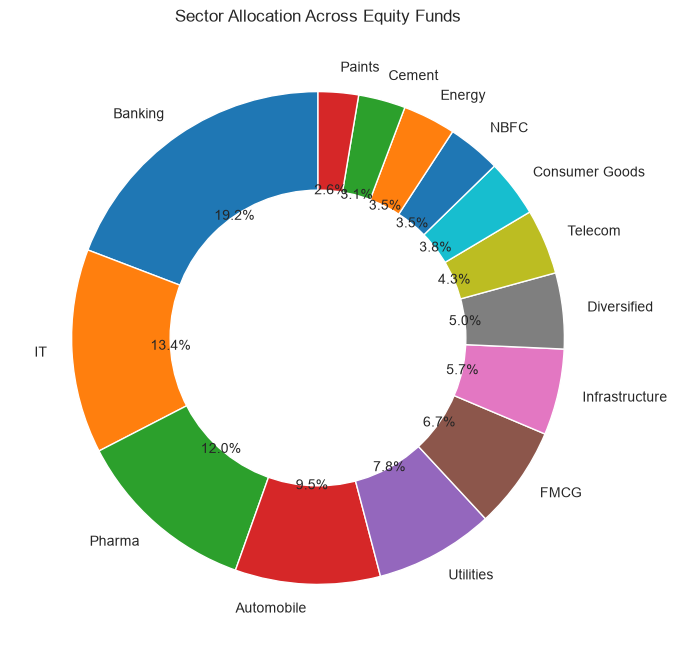

In [21]:
sector = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    sector.values,
    labels=sector.index,
    autopct="%1.1f%%",
    startangle=90
)

centre_circle = plt.Circle((0, 0), 0.60, fc="white")
plt.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Funds")

plt.savefig(
    REPORT_PATH / "12_sector_allocation.png",
    dpi=300
)

plt.show()

Top fund houses collectively dominate the mutual fund market with SBI Mutual Fund having the highest number of schemes.

Average NAV showed an overall upward trend between 2022 and 2025 despite periodic market corrections.

Monthly SIP inflows consistently increased and reached their highest level during the end of 2025.

Equity funds attracted significantly higher inflows compared to debt funds across most months.

Most investors belong to the middle-age categories, indicating stronger participation from working professionals.

Investment amounts are concentrated in T30 cities, although B30 participation is steadily increasing.

Industry folio count nearly doubled from 2022 to 2025, indicating strong retail participation.

Most selected mutual funds exhibit a positive correlation in daily NAV returns.

Financials and Information Technology constitute a major share of portfolio sector allocation.

Expense ratios remain within acceptable regulatory limits for the majority of mutual fund schemes.